In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

In [5]:
df.shape

(541909, 8)

In [6]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [7]:
df = df.drop_duplicates()

In [8]:
df = df[df["UnitPrice"] >= 0]

In [9]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("A")]

In [10]:
df = df[df["Quantity"] != 0]

In [11]:
df.shape

(536638, 9)

In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135034
Country             0
Revenue             0
dtype: int64

In [13]:
top_products = (
    df.groupby("StockCode")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [14]:
top_products

StockCode
22197     56427
84077     53751
85099B    47260
85123A    38811
84879     36122
21212     36016
23084     30597
22492     26437
22616     26299
21977     24719
Name: Quantity, dtype: int64

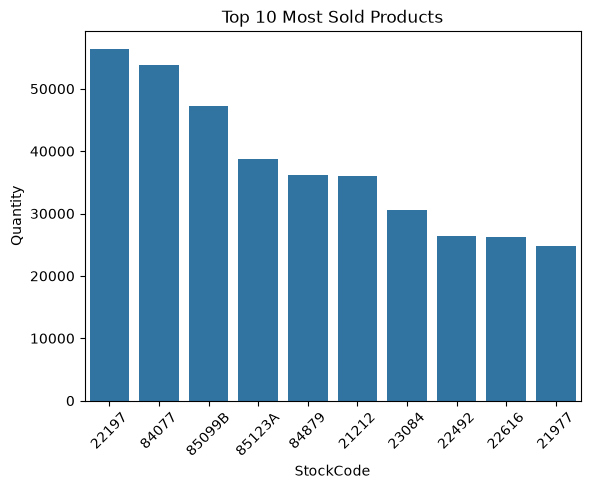

In [15]:
sns.barplot(
    x=top_products.index.astype(str),
    y=top_products.values
)

plt.xlabel("StockCode")
plt.ylabel("Quantity")
plt.title("Top 10 Most Sold Products")
plt.xticks(rotation=45)

plt.show()

In [16]:
top_revenue = (
    df.groupby("StockCode")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue_products = top_revenue.drop("DOT")

In [17]:
top_revenue_products

StockCode
22423     164459.49
47566      98243.88
85123A     97838.45
85099B     92175.79
23084      66661.63
POST       66230.64
22086      63715.24
84879      58792.42
79321      53746.66
Name: Revenue, dtype: float64

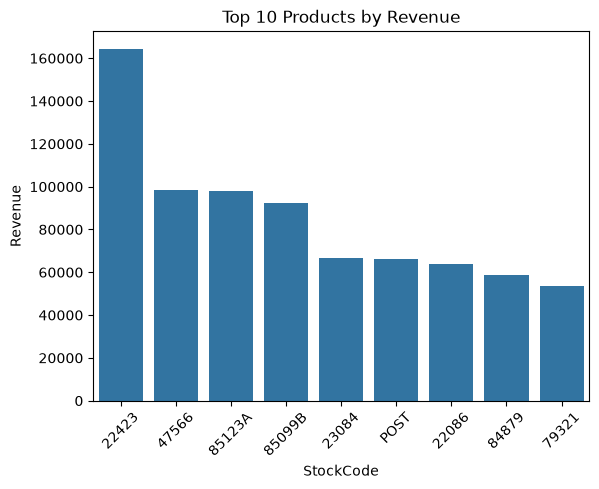

In [18]:
sns.barplot(
    x=top_revenue_products.index.astype(str),
    y=top_revenue_products.values
)

plt.xlabel("StockCode")
plt.ylabel("Revenue")
plt.title("Top 10 Products by Revenue")
plt.xticks(rotation=45)

plt.show()

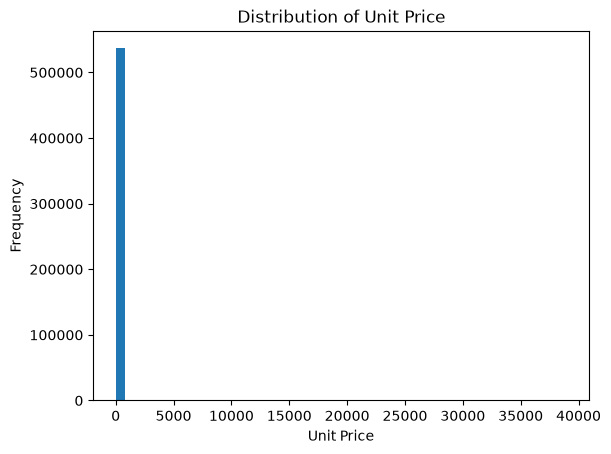

In [19]:
plt.hist(df["UnitPrice"], bins=50)

plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Distribution of Unit Price")

plt.show()

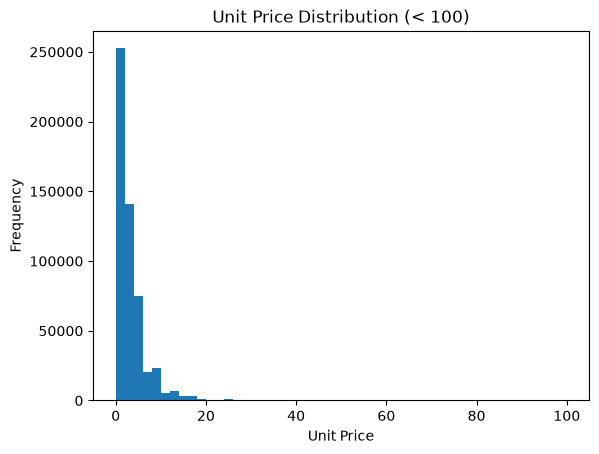

In [21]:
plt.hist(df[df["UnitPrice"] < 100]["UnitPrice"], bins=50)

plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Unit Price Distribution (< 100)")

plt.show()

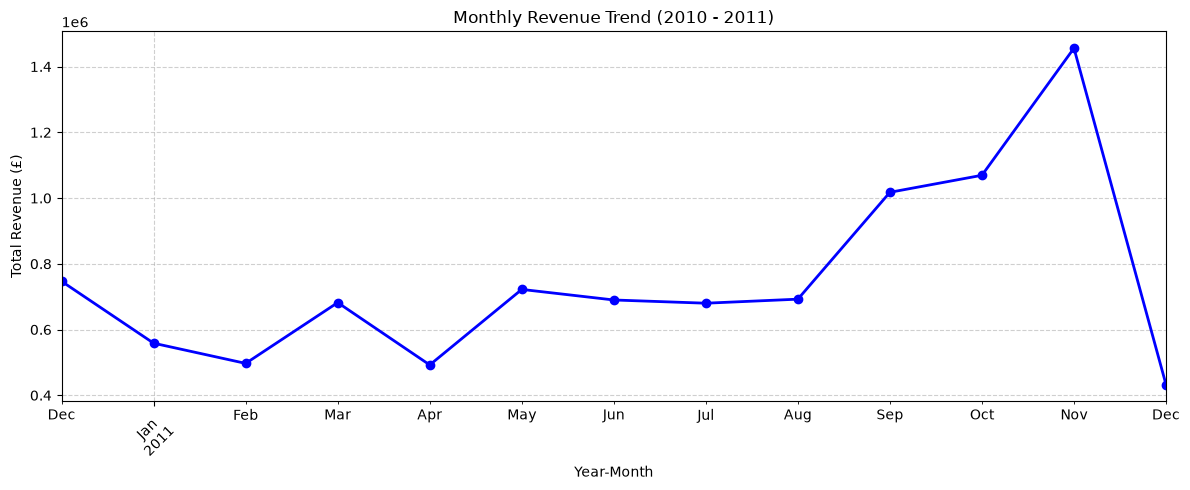

In [23]:
# 1. InvoiceDate sütununu standart datetime (tarih-saat) tipine dönüştürüyoruz.
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# 2. Gün ve saat detaylarını bir kenara bırakıp 'Yıl-Ay' periyoduna geçiyoruz.
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

# 3. Her ayın toplam gelirini (Revenue) hesaplayıp zaman sırasına göre topluyoruz.
monthly_revenue = df.groupby("YearMonth")["Revenue"].sum()

# 4. Zaman serisi çizgi grafiği (Line Plot)
plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind="line", marker="o", color="b", linewidth=2)
plt.title("Monthly Revenue Trend (2010 - 2011)")
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue (£)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

United Kingdom Ciro Payı: %84.57


C:\Users\emine\AppData\Local\Temp\ipykernel_36204\2811522102.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


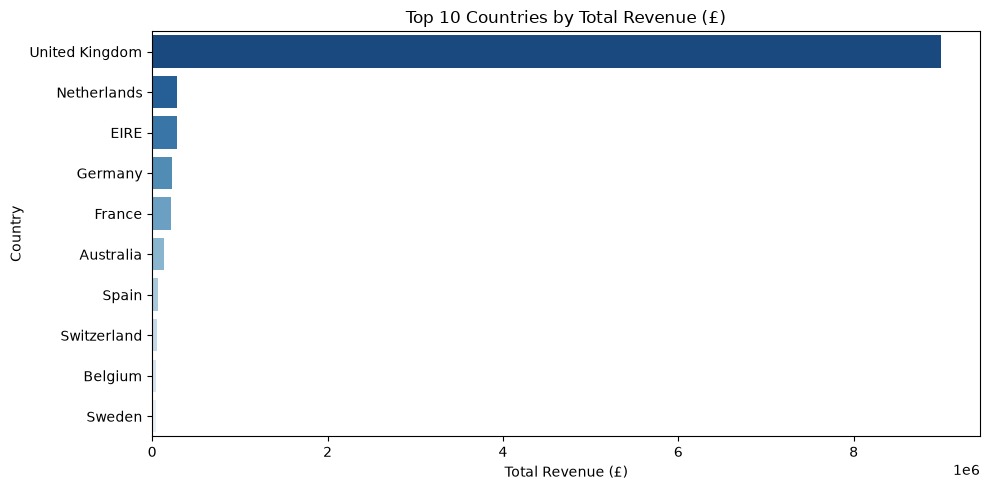

In [24]:
# 1. Pozitif satışları ülkelere göre gruplayıp toplam ciroyu hesaplıyoruz.
country_revenue = (
    df[df["Quantity"] > 0]
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

# 2. İlk 10 ülkeyi alıyoruz
top_10_countries = country_revenue.head(10)

# 3. Yüzdelik pay hesabı: Birleşik Krallık (UK) toplam cironun yüzde kaçını oluşturuyor?
uk_share = (top_10_countries["United Kingdom"] / df[df["Quantity"] > 0]["Revenue"].sum()) * 100
print(f"United Kingdom Ciro Payı: %{uk_share:.2f}")

# 4. Bar Grafiği Görselleştirmesi
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_10_countries.values,
    y=top_10_countries.index,
    palette="Blues_r"
)
plt.title("Top 10 Countries by Total Revenue (£)")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Toplam Tekil Sipariş Sayısı: 25897
Ortalama Sepet Tutarı (AOV - Mean): £375.99
Medyan Sepet Tutarı (Median): £206.33


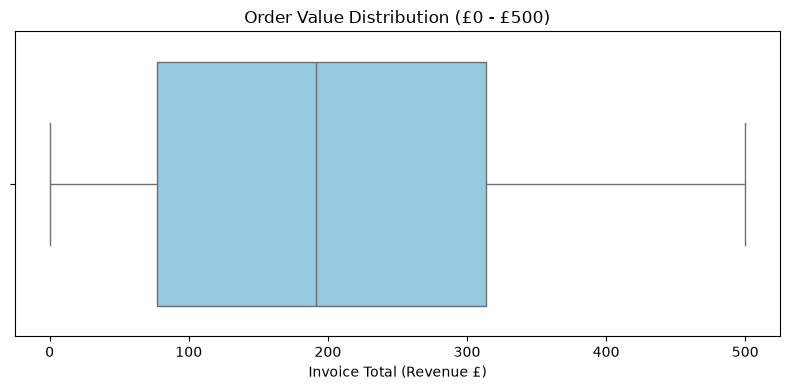

In [25]:
# 1. Her benzersiz faturadaki (InvoiceNo) tüm ürün satırlarının toplam gelirini topluyoruz.
invoice_totals = df.groupby("InvoiceNo")["Revenue"].sum()

# 2. Temel metrikleri ekrana yazdırıyoruz.
print(f"Toplam Tekil Sipariş Sayısı: {invoice_totals.count()}")
print(f"Ortalama Sepet Tutarı (AOV - Mean): £{invoice_totals.mean():.2f}")
print(f"Medyan Sepet Tutarı (Median): £{invoice_totals.median():.2f}")

# 3. Kutu Grafiği (Boxplot) ile sepet tutarı dağılımını görselleştiriyoruz (0 - 500 £ arası tipik siparişler).
plt.figure(figsize=(8, 4))
sns.boxplot(x=invoice_totals[invoice_totals.between(0, 500)], color="skyblue")
plt.title("Order Value Distribution (£0 - £500)")
plt.xlabel("Invoice Total (Revenue £)")
plt.tight_layout()
plt.show()

In [26]:
# 1. 'C' ile başlayan iade kayıtlarını filtreliyoruz.
cancelled_orders = df[df["InvoiceNo"].astype(str).str.startswith("C")]

# 2. İade hacmi ve mali etkisini hesaplıyoruz.
print(f"İptal/İade Edilen İşlem Satırı: {len(cancelled_orders)}")
print(f"İade Edilen Toplam Ürün Adedi: {cancelled_orders['Quantity'].sum()}")
print(f"İadelerin Toplam Mali Değeri: £{cancelled_orders['Revenue'].sum():.2f}")

İptal/İade Edilen İşlem Satırı: 9251
İade Edilen Toplam Ürün Adedi: -275560
İadelerin Toplam Mali Değeri: £-893979.73
